<a href="https://colab.research.google.com/github/busrabhcc/Dogal-Dil-Isleme/blob/main/Do%C4%9Fal_Dil_%C4%B0%C5%9Fleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from collections import Counter
from google.colab import drive

import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import LatentDirichletAllocation


# GOOGLE DRIVE
drive.mount('/content/drive')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Mounted at /content/drive


In [2]:
#VERİ SETİ İŞLEMLERİ
file_path = "/content/drive/MyDrive/NLP_Project/amazon_reviews.csv"

df = pd.read_csv(file_path)

print("=" * 50)
print("Veri Seti Bilgileri")
print("=" * 50)

print("\nVeri Boyutu:")
print(df.shape)

print("\nSütun İsimleri:")
print(df.columns)

print("\nEksik Veri Sayısı:")
print(df.isnull().sum())

Veri Seti Bilgileri

Veri Boyutu:
(4915, 12)

Sütun İsimleri:
Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='object')

Eksik Veri Sayısı:
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64


In [3]:
#TEMİZLEME İŞLEMİ
df = df[['reviewText', 'overall']]

df.dropna(inplace=True)

print("\nTemizleme Sonucu Toplam Boyut:")
print(df.shape)


Temizleme Sonucu Toplam Boyut:
(4914, 2)


In [4]:
#PUAN DAĞILIMLARI
print("\nYıldız Dağılımı:")

print(
    df['overall']
    .value_counts()
    .sort_index()
)



Yıldız Dağılımı:
overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3921
Name: count, dtype: int64


In [5]:
#DUYGU ETİKETLERİ OLUŞTURMA
df_sentiment = df[
    df['overall'] != 3
].copy()

df_sentiment['sentiment'] = df_sentiment[
    'overall'
].apply(
    lambda x: 1 if x >= 4 else 0
)

print("\nDuygu Dağılımı:")

print(
    df_sentiment['sentiment']
    .value_counts()
)


Duygu Dağılımı:
sentiment
1    4448
0     324
Name: count, dtype: int64


In [6]:
#EN SIK BULUNAN KELİMELER
all_text = " ".join(

    df['reviewText']
    .astype(str)
    .str.lower()

)

words = re.findall(
    r'\b[a-z]+\b',
    all_text
)

counter = Counter(words)

print("\nEn Sık Bulunan 20 Kelime:")

print(
    counter.most_common(20)
)


En Sık Bulunan 20 Kelime:
[('i', 9365), ('the', 9223), ('it', 7677), ('and', 7631), ('to', 6163), ('a', 5612), ('my', 5081), ('card', 4718), ('this', 4565), ('for', 4053), ('in', 3413), ('of', 3376), ('is', 3121), ('with', 3073), ('on', 2241), ('have', 2161), ('that', 2072), ('phone', 1782), ('was', 1651), ('s', 1626)]


In [7]:
#STOPWORDS TEMİZLİĞİ
stop_words = set(
    stopwords.words('english')
)

filtered_words = [

    word

    for word in words

    if word not in stop_words

    and len(word) > 2

]

counter_filtered = Counter(
    filtered_words
)

print("\nStopwords Sonrası En Sık Bulunan 30 Kelime:")

print(
    counter_filtered.most_common(30)
)


Stopwords Sonrası En Sık Bulunan 30 Kelime:
[('card', 4718), ('phone', 1782), ('works', 1586), ('great', 1481), ('memory', 1374), ('sandisk', 1339), ('use', 1125), ('one', 1103), ('galaxy', 1024), ('cards', 938), ('fast', 923), ('good', 904), ('price', 872), ('samsung', 842), ('bought', 838), ('storage', 781), ('would', 702), ('well', 693), ('tablet', 681), ('speed', 671), ('class', 623), ('music', 619), ('using', 599), ('micro', 566), ('got', 564), ('get', 554), ('product', 545), ('camera', 544), ('like', 525), ('adapter', 523)]


In [8]:
#LEMMATIZATION İŞLEMİ
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'http\S+',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    words = text.split()

    words = [

        lemmatizer.lemmatize(word)

        for word in words

        if word not in stop_words

        and len(word) > 2

    ]

    return " ".join(words)

df_sentiment["clean_review"] = (

    df_sentiment["reviewText"]

    .apply(clean_text)

)

In [9]:
#EĞİTİM VE TEST SETİNE AYIRMA
X = df_sentiment["clean_review"]

y = df_sentiment["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


In [10]:
#TF-IDF
tfidf = TfidfVectorizer(

    max_features=5000,

    ngram_range=(1,2)

)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print("\nTF-IDF Matris Boyutları:")

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)


TF-IDF Matris Boyutları:
(3817, 5000)
(955, 5000)


In [12]:
#LOGISTIC REGRESYON
lr = LogisticRegression(

    max_iter=1000,

    class_weight='balanced'

)

lr.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = lr.predict(
    X_test_tfidf
)

print("\nLOGISTIC REGRESYON")

print("Doğruluk Oranı:",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)



LOGISTIC REGRESYON
Doğruluk Oranı: 0.9528795811518325
              precision    recall  f1-score   support

           0       0.61      0.83      0.71        65
           1       0.99      0.96      0.97       890

    accuracy                           0.95       955
   macro avg       0.80      0.90      0.84       955
weighted avg       0.96      0.95      0.96       955



In [14]:
#RANDOM FOREST
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight='balanced'

)

rf.fit(
    X_train_tfidf,
    y_train
)

y_pred_rf = rf.predict(
    X_test_tfidf
)

print("\nRANDOM FOREST")

print("Doğruluk Oranı:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)


RANDOM FOREST
Doğruluk Oranı: 0.9329842931937172
              precision    recall  f1-score   support

           0       0.67      0.03      0.06        65
           1       0.93      1.00      0.97       890

    accuracy                           0.93       955
   macro avg       0.80      0.51      0.51       955
weighted avg       0.92      0.93      0.90       955



In [15]:
#LINEAR SVM
svm = LinearSVC(
    class_weight='balanced'
)

svm.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm.predict(
    X_test_tfidf
)

print("\nLINEAR SVM")

print("Doğruluk Oranı:",
    accuracy_score(
        y_test,
        y_pred_svm
    )
)

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)


LINEAR SVM
Doğruluk Oranı: 0.9654450261780104
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        65
           1       0.98      0.98      0.98       890

    accuracy                           0.97       955
   macro avg       0.87      0.85      0.86       955
weighted avg       0.96      0.97      0.97       955



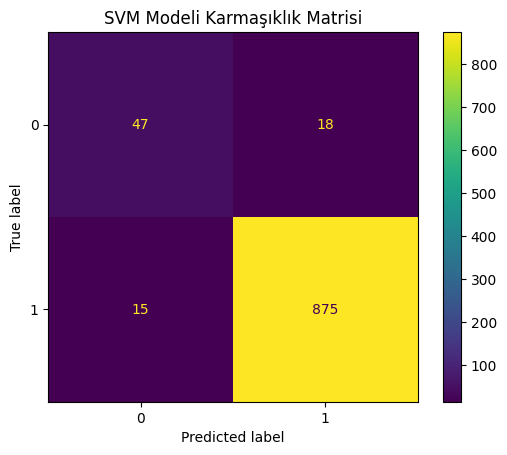

In [16]:
#KARMAŞIKLIK MATRİSİ
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)
plt.title("SVM Modeli Karmaşıklık Matrisi")
plt.show()


F1 SCORU :
{'Random Forest': 0.9035608581478536, 'Logistic Regression': 0.9561128971728029, 'Linear SVM': 0.965065966930905}


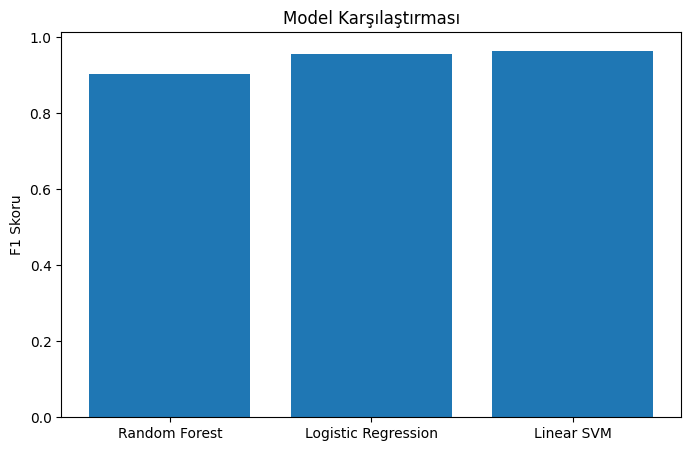

In [17]:
#F1 SCORE VE MODEL KARŞILAŞTIRMA
results = {

    "Random Forest":

        f1_score(
            y_test,
            y_pred_rf,
            average='weighted'
        ),

    "Logistic Regression":

        f1_score(
            y_test,
            y_pred_lr,
            average='weighted'
        ),

    "Linear SVM":

        f1_score(
            y_test,
            y_pred_svm,
            average='weighted'
        )

}

print("\nF1 SCORU :")

print(results)

plt.figure(figsize=(8,5))

plt.bar(
    list(results.keys()),
    list(results.values())
)

plt.title(
    "Model Karşılaştırması"
)

plt.ylabel(
    "F1 Skoru"
)

plt.show()


In [18]:
#NEGATİF YORUM ANALİZİ
negative_reviews = df_sentiment[
    df_sentiment["sentiment"] == 0
]

negative_docs = negative_reviews[
    "clean_review"
]

In [19]:
#KELİME SAYIMI
vectorizer = CountVectorizer(

    max_features=3000,

    stop_words='english'

)

X_counts = vectorizer.fit_transform(
    negative_docs
)

In [20]:
#LDA MODELİ EĞİTİMİ
lda = LatentDirichletAllocation(

    n_components=5,

    random_state=42

)

lda.fit(
    X_counts
)

LatentDirichletAllocation(n_components=5, random_state=42)

In [21]:
#NEGATİF YORUMLARDAKİ ANA KONULAR
def print_topics(
    model,
    vectorizer,
    n_words=10
):

    words = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(
        model.components_
    ):

        print(
            f"\nTopic {topic_idx+1}"
        )

        top_words = [

            words[i]

            for i in topic.argsort()[-n_words:]

        ]

        print(
            " | ".join(
                top_words
            )
        )

print_topics(
    lda,
    vectorizer
)



Topic 1
replacement | failed | samsung | got | file | galaxy | month | phone | sandisk | card

Topic 2
problem | sec | amazon | memory | read | sandisk | class | write | speed | card

Topic 3
worked | read | product | tried | data | work | problem | sandisk | phone | card

Topic 4
use | device | time | memory | camera | problem | speed | sandisk | class | card

Topic 5
say | write | know | amazon | hot | got | problem | format | sandisk | card


In [22]:
#YORUMLARA KONU ATAMA
doc_topics = lda.transform(
    X_counts
)

negative_reviews = negative_reviews.copy()

negative_reviews["topic"] = np.argmax(
    doc_topics,
    axis=1
)

In [23]:
#KONU DAĞILIMI
topic_distribution = (

    negative_reviews["topic"]

    .value_counts()

    .sort_index()

)

print("\nNegatif Konu Dağılımı")

print(
    topic_distribution
)


Negatif Konu Dağılımı
topic
0    124
1     34
2     99
3     49
4     18
Name: count, dtype: int64


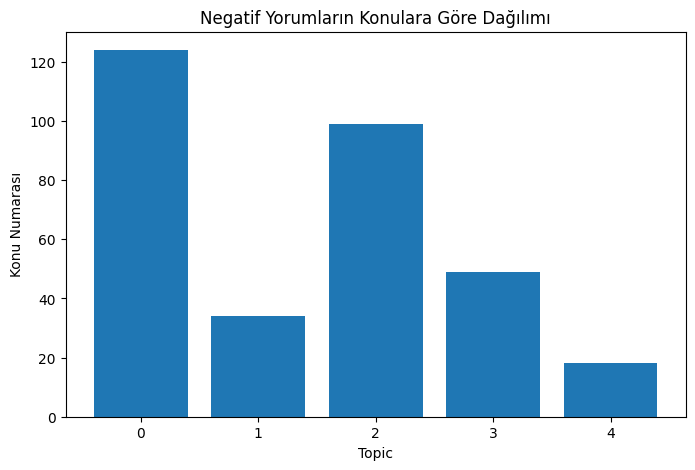

In [24]:
#GRAFİK-GÖRSEL
plt.figure(figsize=(8,5))

plt.bar(

    topic_distribution.index.astype(str),

    topic_distribution.values

)

plt.title(
    "Negatif Yorumların Konulara Göre Dağılımı"
)

plt.xlabel(
    "Topic"
)

plt.ylabel(
    "Konu Numarası"
)

plt.show()

In [26]:
#EN PROBLEMLİ KONU ANALİZİ
worst_topic = topic_distribution.idxmax()

print(
    "\nEn Fazla Şikayet İçeren Konu:",
    worst_topic + 1
)

words = vectorizer.get_feature_names_out()

top_words = [

    words[i]

    for i in lda.components_[worst_topic].argsort()[-10:]

]

print(
    "\nAnahtar Kelimeler:"
)

print(top_words)



En Fazla Şikayet İçeren Konu: 1

Anahtar Kelimeler:
['replacement', 'failed', 'samsung', 'got', 'file', 'galaxy', 'month', 'phone', 'sandisk', 'card']
